# PCA from Scratch (Pandas + Pure Math)
Principal Component Analysis on California Housing (8 features).
Covariance matrix and projections computed with pandas; eigendecomposition via `np.linalg.eigh`.
Model saved to `../Models/pca_scratch.json`.

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
from sklearn.datasets import fetch_california_housing

raw      = fetch_california_housing(as_frame=True)
df       = raw.frame[raw.feature_names].copy()
features = list(raw.feature_names)
n, p     = df.shape

print(f"Shape: {n:,} rows × {p} features")
df.head(3)

Shape: 20,640 rows × 8 features


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


## 2. Standardise (Zero Mean, Unit Variance)

PCA is sensitive to scale. A feature measured in thousands will dominate one measured in fractions
unless we standardise first.
$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

In [2]:
col_mean = df.mean()
col_std  = df.std(ddof=1)          # sample std — matches numpy/sklearn defaults

X = (df - col_mean) / col_std      # shape (n, p), pandas DataFrame

print(f"Post-scale mean (should be ~0): {X.mean().round(10).tolist()}")
print(f"Post-scale std  (should be ~1): {X.std().round(4).tolist()}")

Post-scale mean (should be ~0): [0.0, 0.0, 0.0, -0.0, -0.0, 0.0, 0.0, -0.0]
Post-scale std  (should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 3. Covariance Matrix

For standardised data the covariance matrix equals the **correlation matrix**:
$$C = \frac{1}{n-1} X^T X \quad \in \mathbb{R}^{p \times p}$$

Each entry $C_{ij}$ is the covariance between feature $i$ and feature $j$.
The diagonal entries are 1 (because features are standardised).

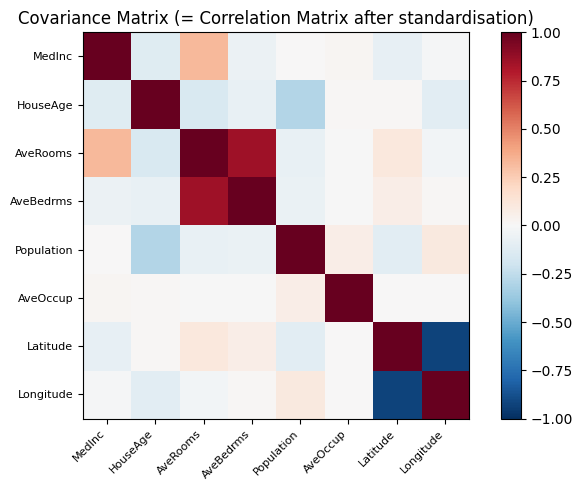

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


In [3]:
C = X.T.dot(X) / (n - 1)          # (p, p) covariance matrix via pandas

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(C.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(p)); ax.set_yticks(range(p))
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(features, fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Covariance Matrix (= Correlation Matrix after standardisation)')
plt.tight_layout(); plt.show()
C

## 4. Eigendecomposition

The covariance matrix is **symmetric positive semi-definite**, so its eigendecomposition is:
$$C = V \Lambda V^T$$

- $V$ — matrix of **eigenvectors** (principal directions), one per column
- $\Lambda$ — diagonal matrix of **eigenvalues** (variance explained per direction)

We use `np.linalg.eigh` (optimised for symmetric matrices, always returns real values)
and sort eigenvalues in **descending** order.

In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(C.values)   # eigh for symmetric matrices

# eigh returns ascending order — reverse to descending
order        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]                  # columns = principal directions

# Explained variance
explained_var_ratio  = eigenvalues / eigenvalues.sum()
cumulative_var_ratio = explained_var_ratio.cumsum()

ev_df = pd.DataFrame({
    'PC':                 [f'PC{i+1}' for i in range(p)],
    'Eigenvalue':         eigenvalues.round(4),
    'Explained Var (%)':  (explained_var_ratio * 100).round(2),
    'Cumulative Var (%)': (cumulative_var_ratio * 100).round(2)
}).set_index('PC')
ev_df

,Eigenvalue,Explained Var (%),Cumulative Var (%)
PC,,,
PC1,2.0269,25.34,25.34
PC2,1.8813,23.52,48.85
PC3,1.2711,15.89,64.74
PC4,1.0310,12.89,77.63
PC5,1.0031,12.54,90.17
PC6,0.6594,8.24,98.41
PC7,0.0816,1.02,99.43
PC8,0.0456,0.57,100.00


## 5. Scree Plot

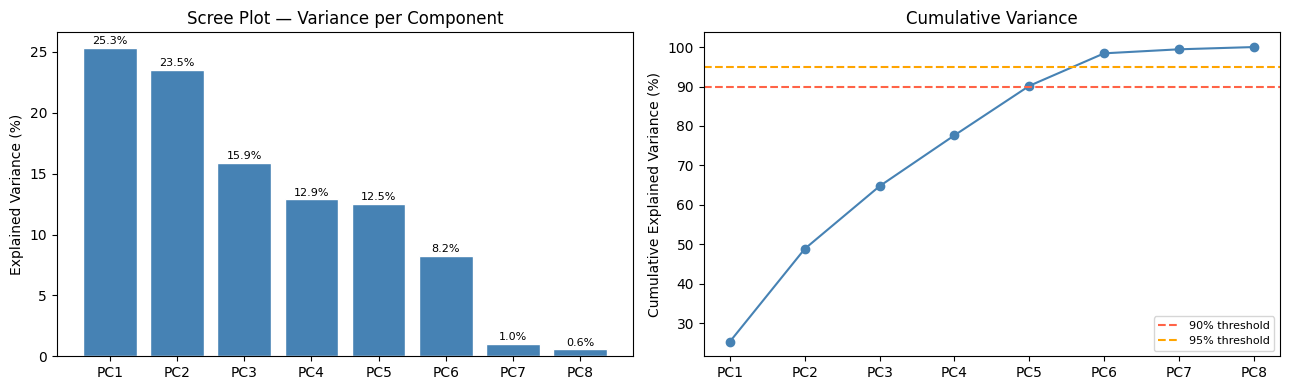

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

pcs = [f'PC{i+1}' for i in range(p)]
ax1.bar(pcs, explained_var_ratio * 100, color='steelblue', edgecolor='white')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot — Variance per Component')
for i, v in enumerate(explained_var_ratio * 100):
    ax1.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

ax2.plot(pcs, cumulative_var_ratio * 100, marker='o', color='steelblue')
ax2.axhline(90, linestyle='--', color='tomato', label='90% threshold')
ax2.axhline(95, linestyle='--', color='orange', label='95% threshold')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Variance')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 6. Project Data onto Principal Components

$$X_{\text{PCA}} = X_{\text{std}} \cdot V_k$$

where $V_k$ contains the first $k$ eigenvectors (columns).
The result is a compressed representation in $k$-dimensional space.

In [6]:
K = 2    # project to 2D for visualisation

V_k    = pd.DataFrame(eigenvectors[:, :K], index=features, columns=[f'PC{i+1}' for i in range(K)])
X_pca  = X.dot(V_k)    # (n, K) — the compressed representation

print(f"Original shape : {X.shape}")
print(f"Projected shape: {X_pca.shape}")
print(f"Variance retained: {cumulative_var_ratio[K-1]*100:.2f}%")
X_pca.head(3)

Original shape : (20640, 8)
Projected shape: (20640, 2)
Variance retained: 48.85%


,PC1,PC2
0,-1.882659,0.503350
1,-1.371086,0.121403
2,-2.086817,0.501124


## 7. 2D Scatter Plot (Coloured by Target)

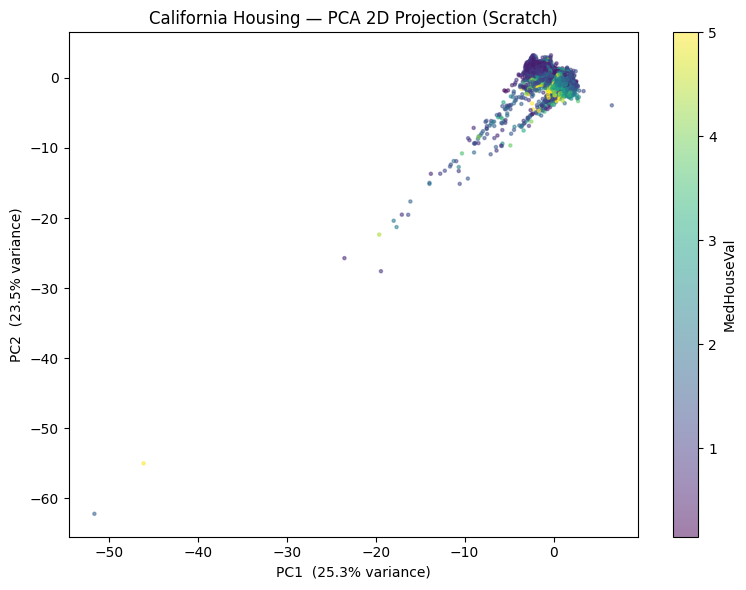

In [7]:
y = raw.frame['MedHouseVal'].values

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca['PC1'], X_pca['PC2'], c=y, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc, ax=ax, label='MedHouseVal')
ax.set_xlabel(f'PC1  ({explained_var_ratio[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({explained_var_ratio[1]*100:.1f}% variance)')
ax.set_title('California Housing — PCA 2D Projection (Scratch)')
plt.tight_layout(); plt.show()

## 8. Loadings Plot (Biplot)

Arrows show how much each original feature contributes to PC1 and PC2.
Features pointing in the same direction are positively correlated.

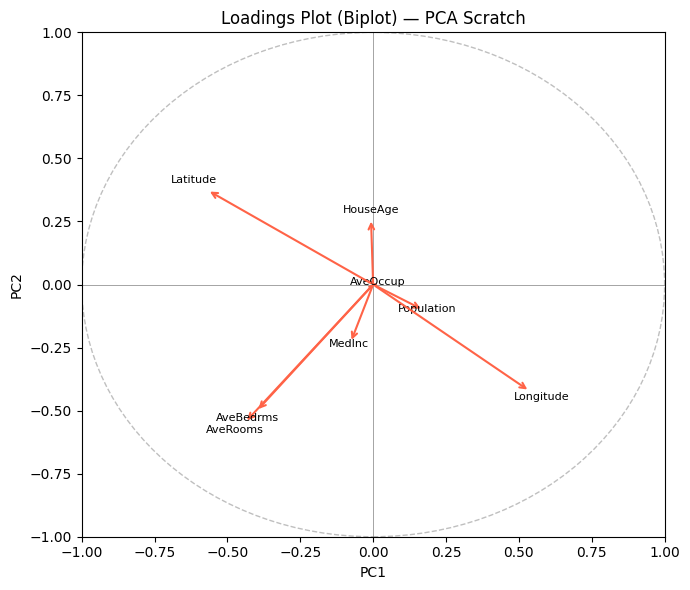

In [8]:
loadings = V_k.copy()

fig, ax = plt.subplots(figsize=(7, 6))
for feat in features:
    ax.annotate('', xy=(loadings.loc[feat, 'PC1'], loadings.loc[feat, 'PC2']),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
    ax.text(loadings.loc[feat, 'PC1']*1.08, loadings.loc[feat, 'PC2']*1.08,
            feat, fontsize=8, ha='center')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
circle = plt.Circle((0,0), 1, fill=False, linestyle='--', color='grey', alpha=0.5)
ax.add_patch(circle)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Loadings Plot (Biplot) — PCA Scratch')
plt.tight_layout(); plt.show()

## 9. Reconstruction & Reconstruction Error

Project back to original space to see how much information is lost:
$$\hat{X} = X_{\text{PCA}} \cdot V_k^T \cdot \sigma + \mu$$

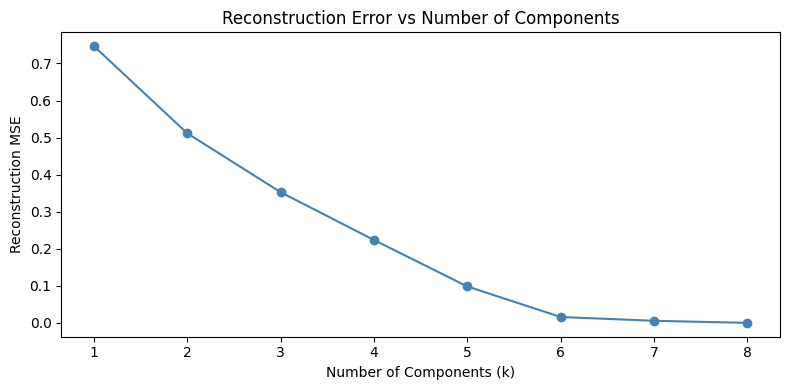

Reconstruction MSE per k:
  k=1: 0.746595
  k=2: 0.511444
  k=3: 0.352565
  k=4: 0.223692
  k=5: 0.098316
  k=6: 0.015898
  k=7: 0.005698
  k=8: 0.000000


In [9]:
recon_errors = []
for k in range(1, p + 1):
    Vk       = pd.DataFrame(eigenvectors[:, :k], index=features)
    X_proj   = X.dot(Vk)                   # (n, k)
    X_recon  = X_proj.dot(Vk.T)            # (n, p) — back in standardised space
    mse      = ((X.values - X_recon.values) ** 2).mean()
    recon_errors.append(mse)

plt.figure(figsize=(8, 4))
plt.plot(range(1, p + 1), recon_errors, marker='o', color='steelblue')
plt.xlabel('Number of Components (k)')
plt.ylabel('Reconstruction MSE')
plt.title('Reconstruction Error vs Number of Components')
plt.xticks(range(1, p + 1))
plt.tight_layout(); plt.show()

print("Reconstruction MSE per k:")
for k, err in enumerate(recon_errors, 1):
    print(f"  k={k}: {err:.6f}")

## 10. Save Model to `../Models/`

In [10]:
model_data = {
    'feature_names':        features,
    'col_mean':             col_mean.to_dict(),
    'col_std':              col_std.to_dict(),
    'components':           eigenvectors.tolist(),          # (p, p) all components
    'eigenvalues':          eigenvalues.tolist(),
    'explained_var_ratio':  explained_var_ratio.tolist(),
    'cumulative_var_ratio': cumulative_var_ratio.tolist()
}

save_path = '../Models/pca_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/pca_scratch.json  (2.5 KB)
